In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "benchmark").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.config import RESULT_DIR
from benchmark.examples.diffusion.results.summary_dimension_comparison import (
    CALIBRATION_THRESHOLD_PATH,
    MODEL_SETS,
    NO_MMD_SUMMARY_SPECS,
    display_gold_pmp_lowess_grid,
    display_summary_dimension_comparison,
    generate_calibrated_gold_pmp_lowess_grid,
    run_calibrated_comparison_pipeline,
)

from benchmark.examples.diffusion.calibration.thresholds import (
    calculate_and_save_thresholds,
)


INFO:bayesflow:Using backend 'tensorflow'


In [2]:
METRICS = ("density",)
# Configure x globally and y separately for each result type.
XSCALE = "symlog"
YSCALE = {"posterior_mmd": "linear", "logml": "symlog", "pmp": "linear"}
NORMALIZE_METRICS = False  # Applies to posterior MMD/logML only; PMP always remains raw.
OUTPUT_ROOT = RESULT_DIR / "plots" / "summary_diagnostics_noMMD_calibrated_thresholds"
OVERLAY_OUTPUT_ROOT = RESULT_DIR / "plots" / "diagnostic_overlays_calibrated_noMMD"
THRESHOLD_PATH = CALIBRATION_THRESHOLD_PATH


In [ ]:
# Refresh the shared calibration thresholds using the requested intervals.
POSTERIOR_MMD_QUANTILE = 0.95
SIGNED_ERROR_COVERAGE = 0.90
CALIBRATION_ROOT = CALIBRATION_THRESHOLD_PATH.parent
THRESHOLD_RESULTS_PATH = CALIBRATION_ROOT / "per_dataset_results.csv"

calibration_thresholds, _ = calculate_and_save_thresholds(
    input_path=CALIBRATION_ROOT / "per_dataset_metrics.csv",
    thresholds_path=THRESHOLD_PATH,
    results_path=THRESHOLD_RESULTS_PATH,
    quantile=POSTERIOR_MMD_QUANTILE,
    signed_error_coverage=SIGNED_ERROR_COVERAGE,
)

posterior_rows = calibration_thresholds["metric"].eq("posterior_mmd")
signed_error_rows = calibration_thresholds["metric"].isin(
    ["signed_logml_error", "signed_pmp_error"]
)
assert calibration_thresholds.loc[posterior_rows, "lower_quantile"].eq(0.0).all()
assert calibration_thresholds.loc[posterior_rows, "upper_quantile"].eq(0.95).all()
assert (
    calibration_thresholds.loc[signed_error_rows, "lower_quantile"]
    .sub(0.05)
    .abs()
    .lt(1e-12)
    .all()
)
assert calibration_thresholds.loc[signed_error_rows, "upper_quantile"].eq(0.95).all()
print(f"Thresholds refreshed: {THRESHOLD_PATH}")


all_density /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_diagnostics_noMMD_calibrated_thresholds/all/density


## Simulated datasets

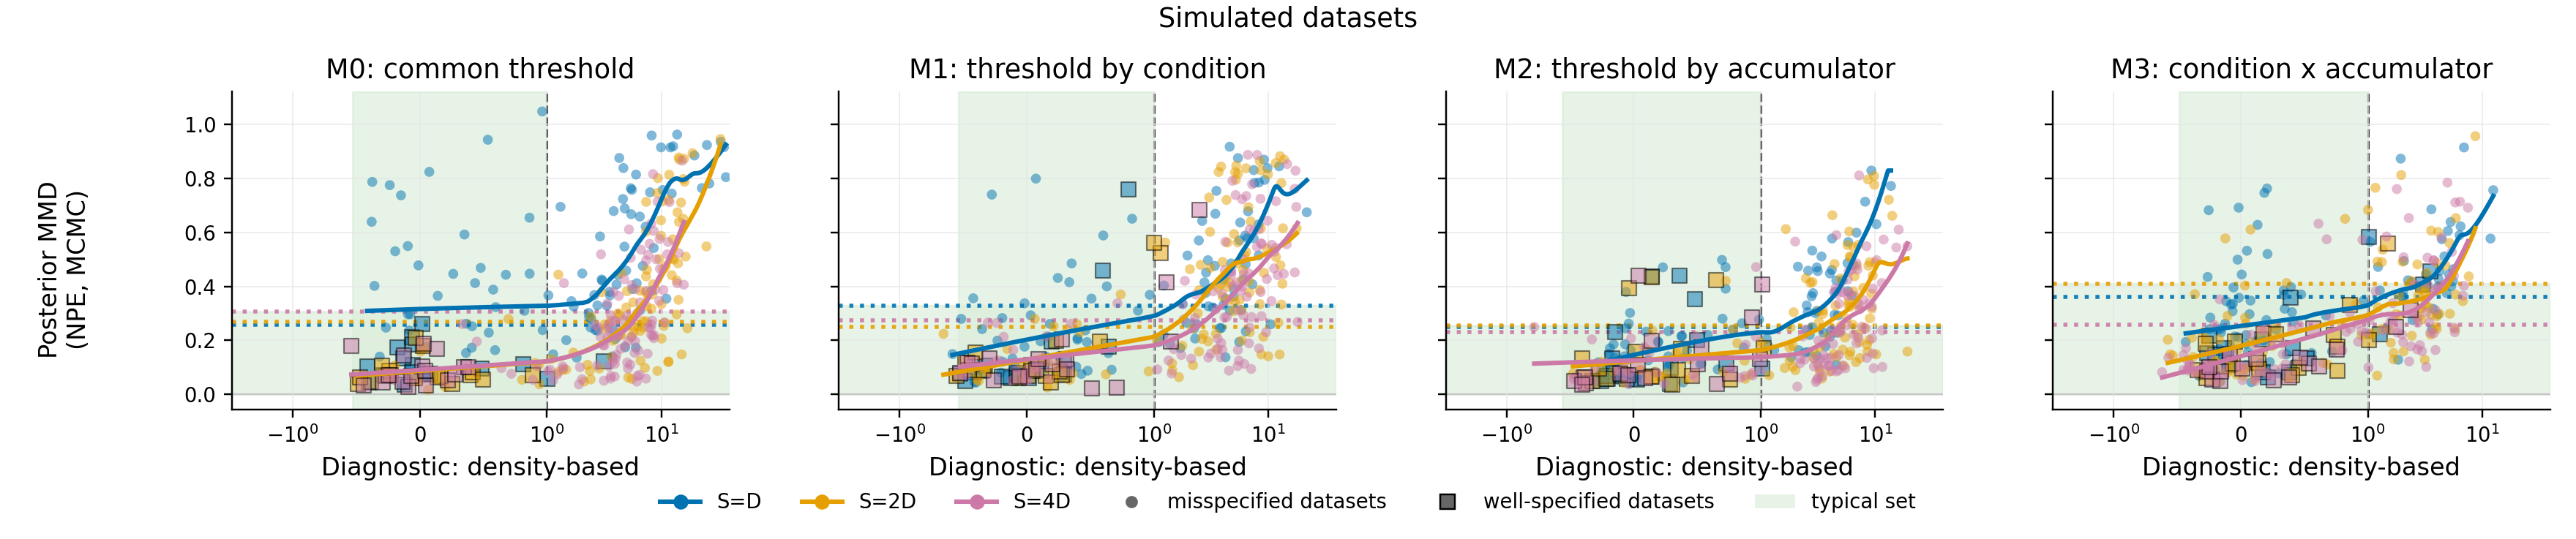

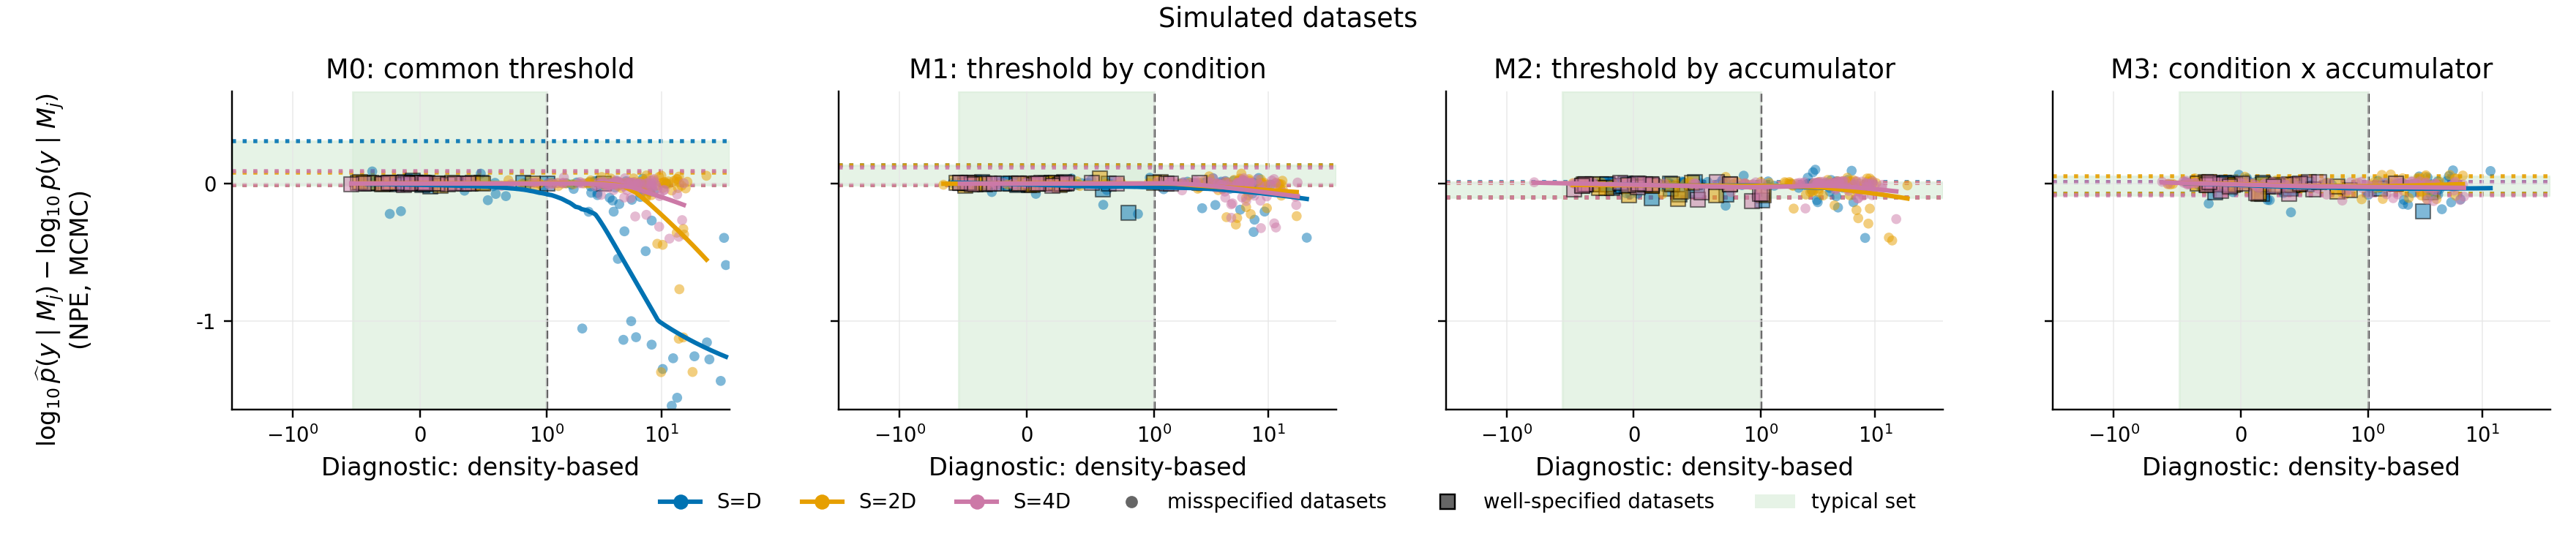

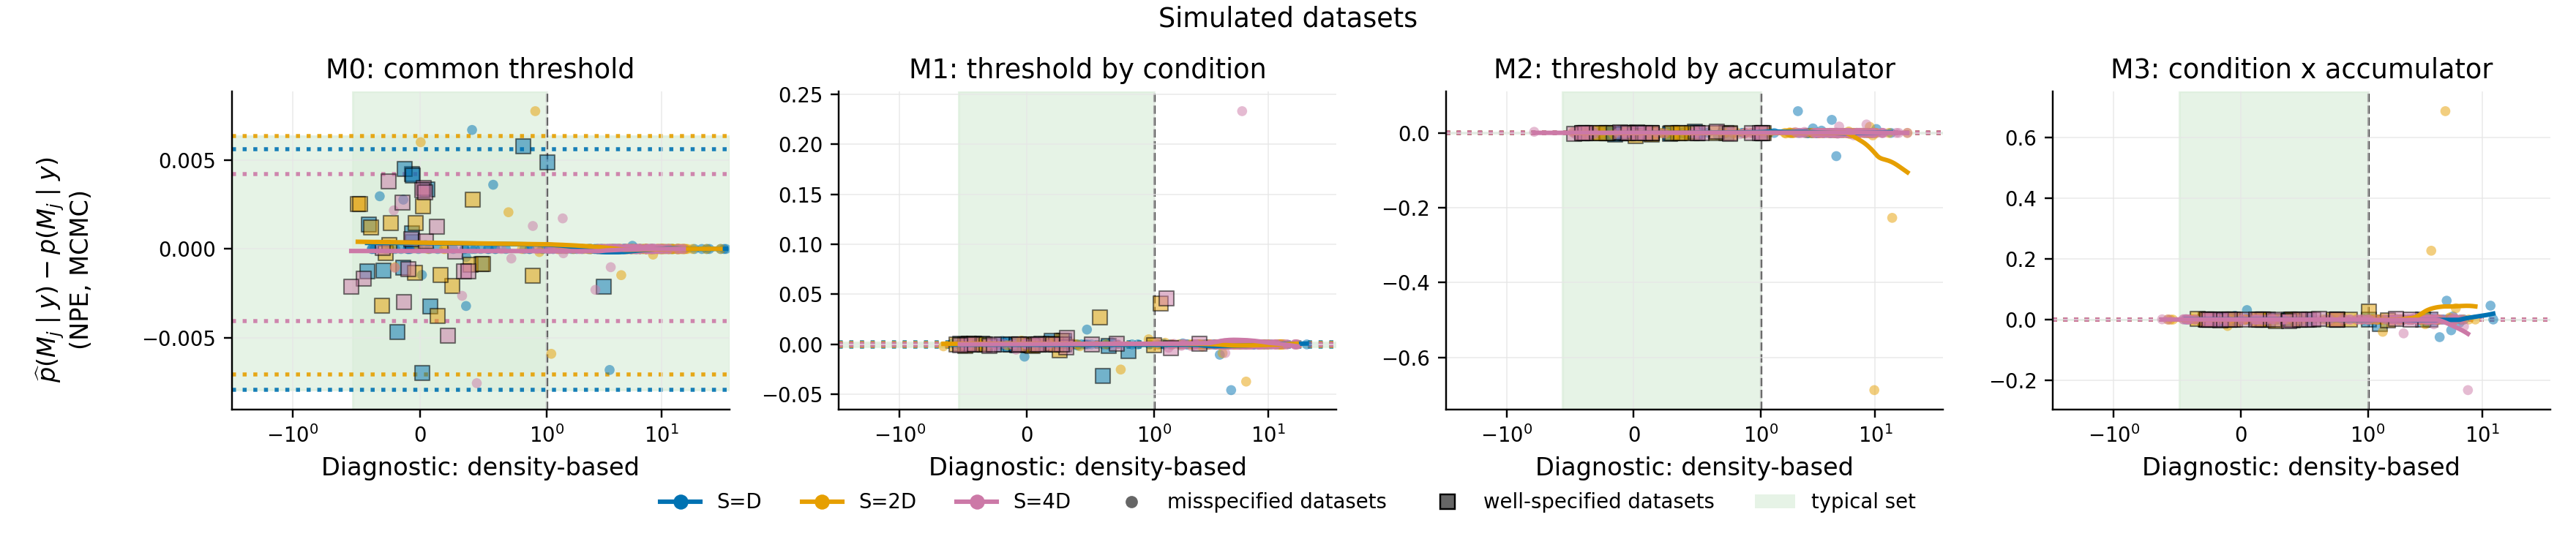

## Empirical datasets

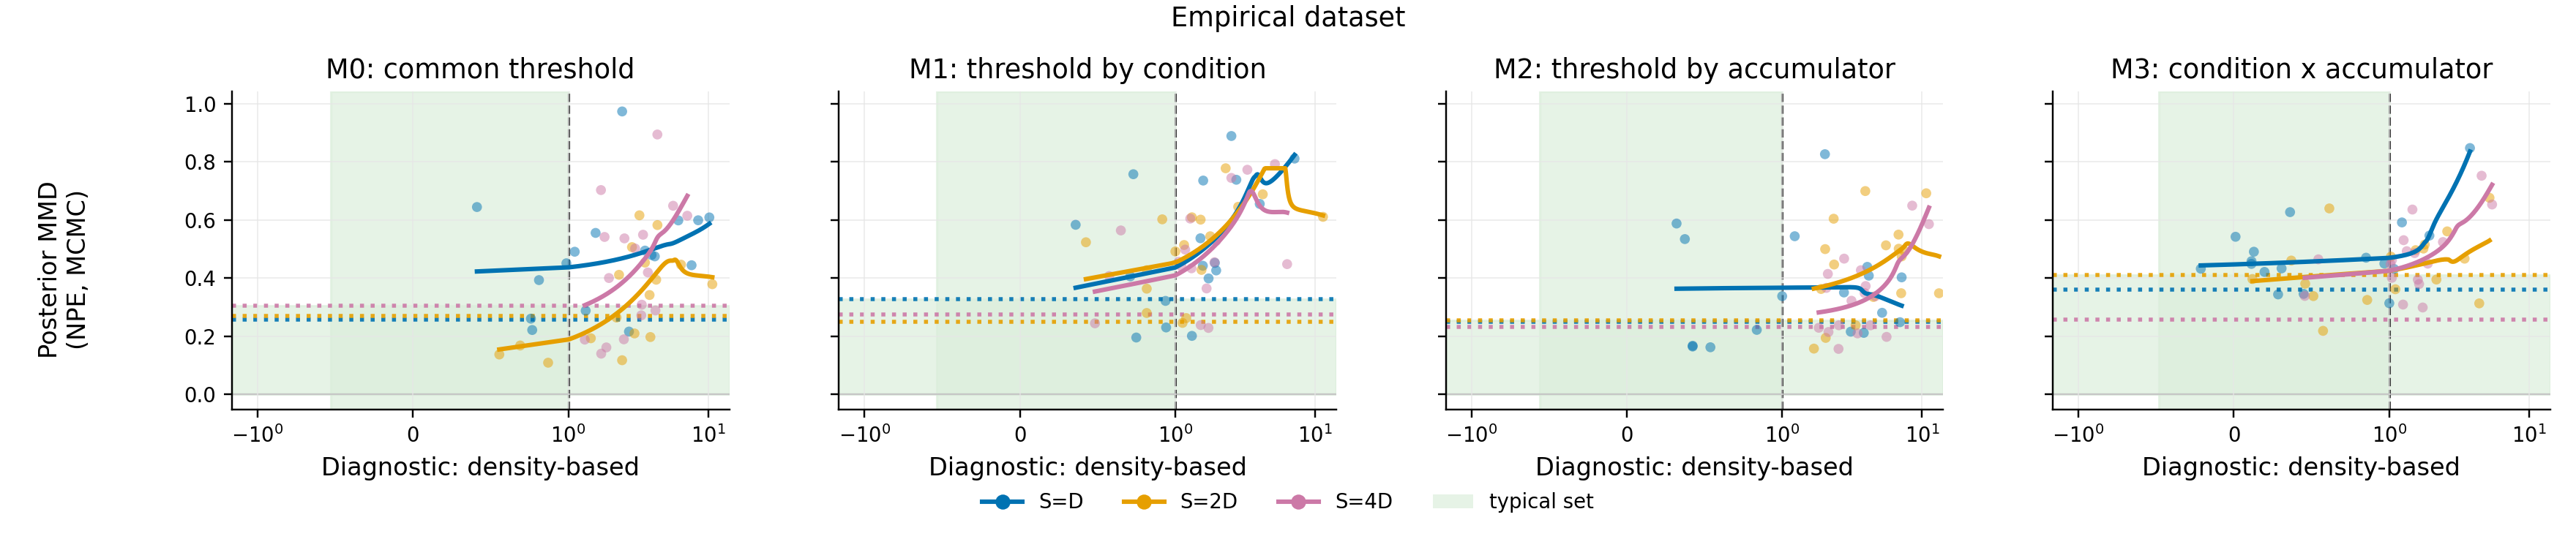

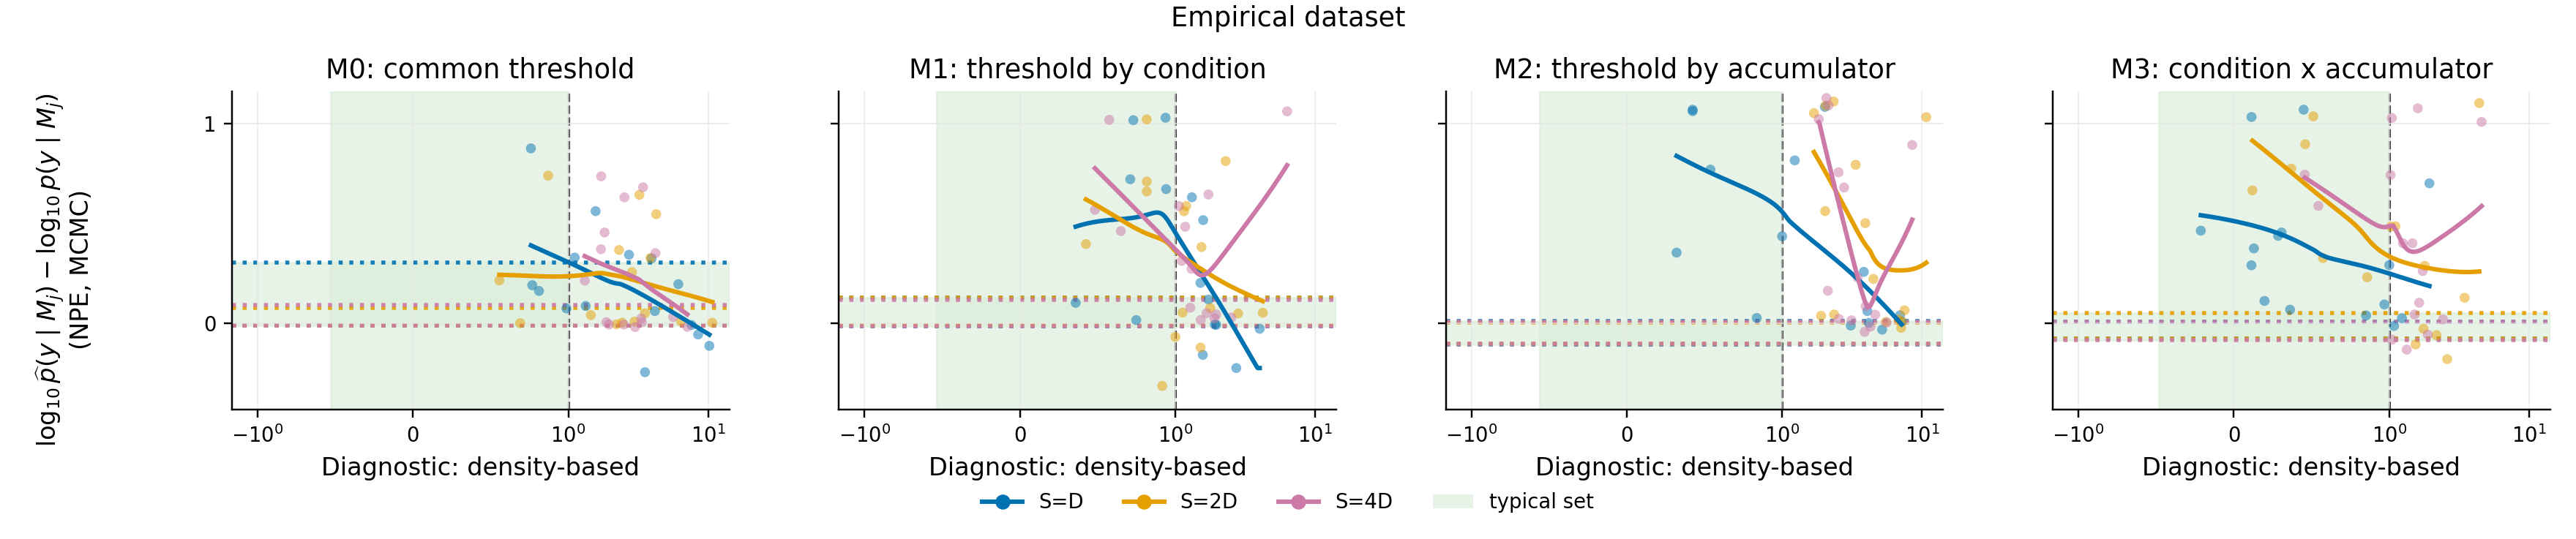

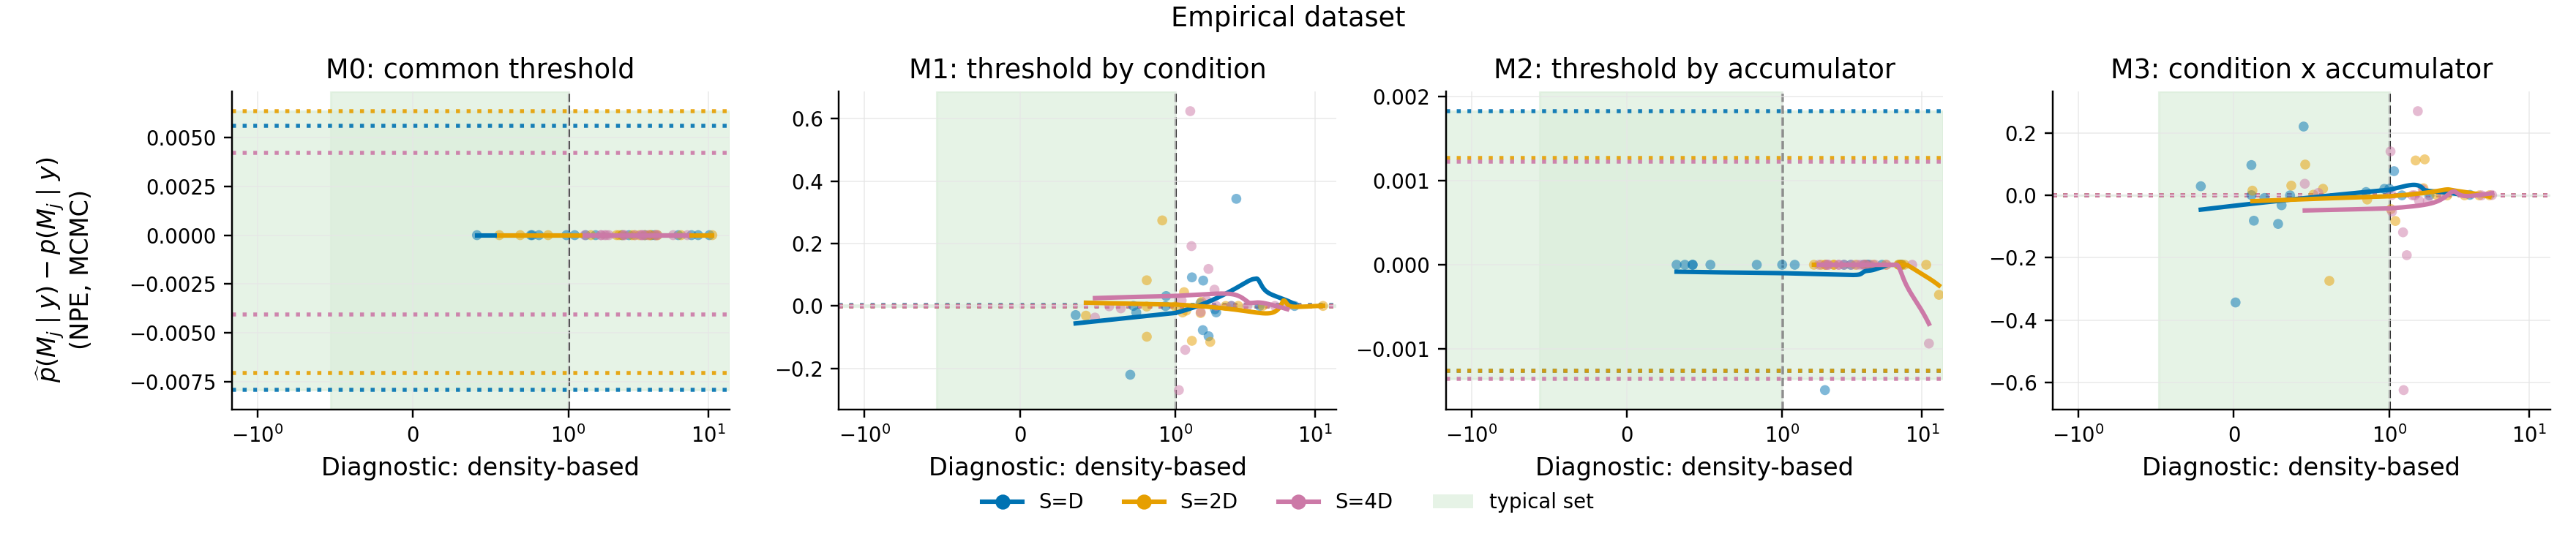

m1_m3_density /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_diagnostics_noMMD_calibrated_thresholds/m1_m3/density


## Simulated datasets

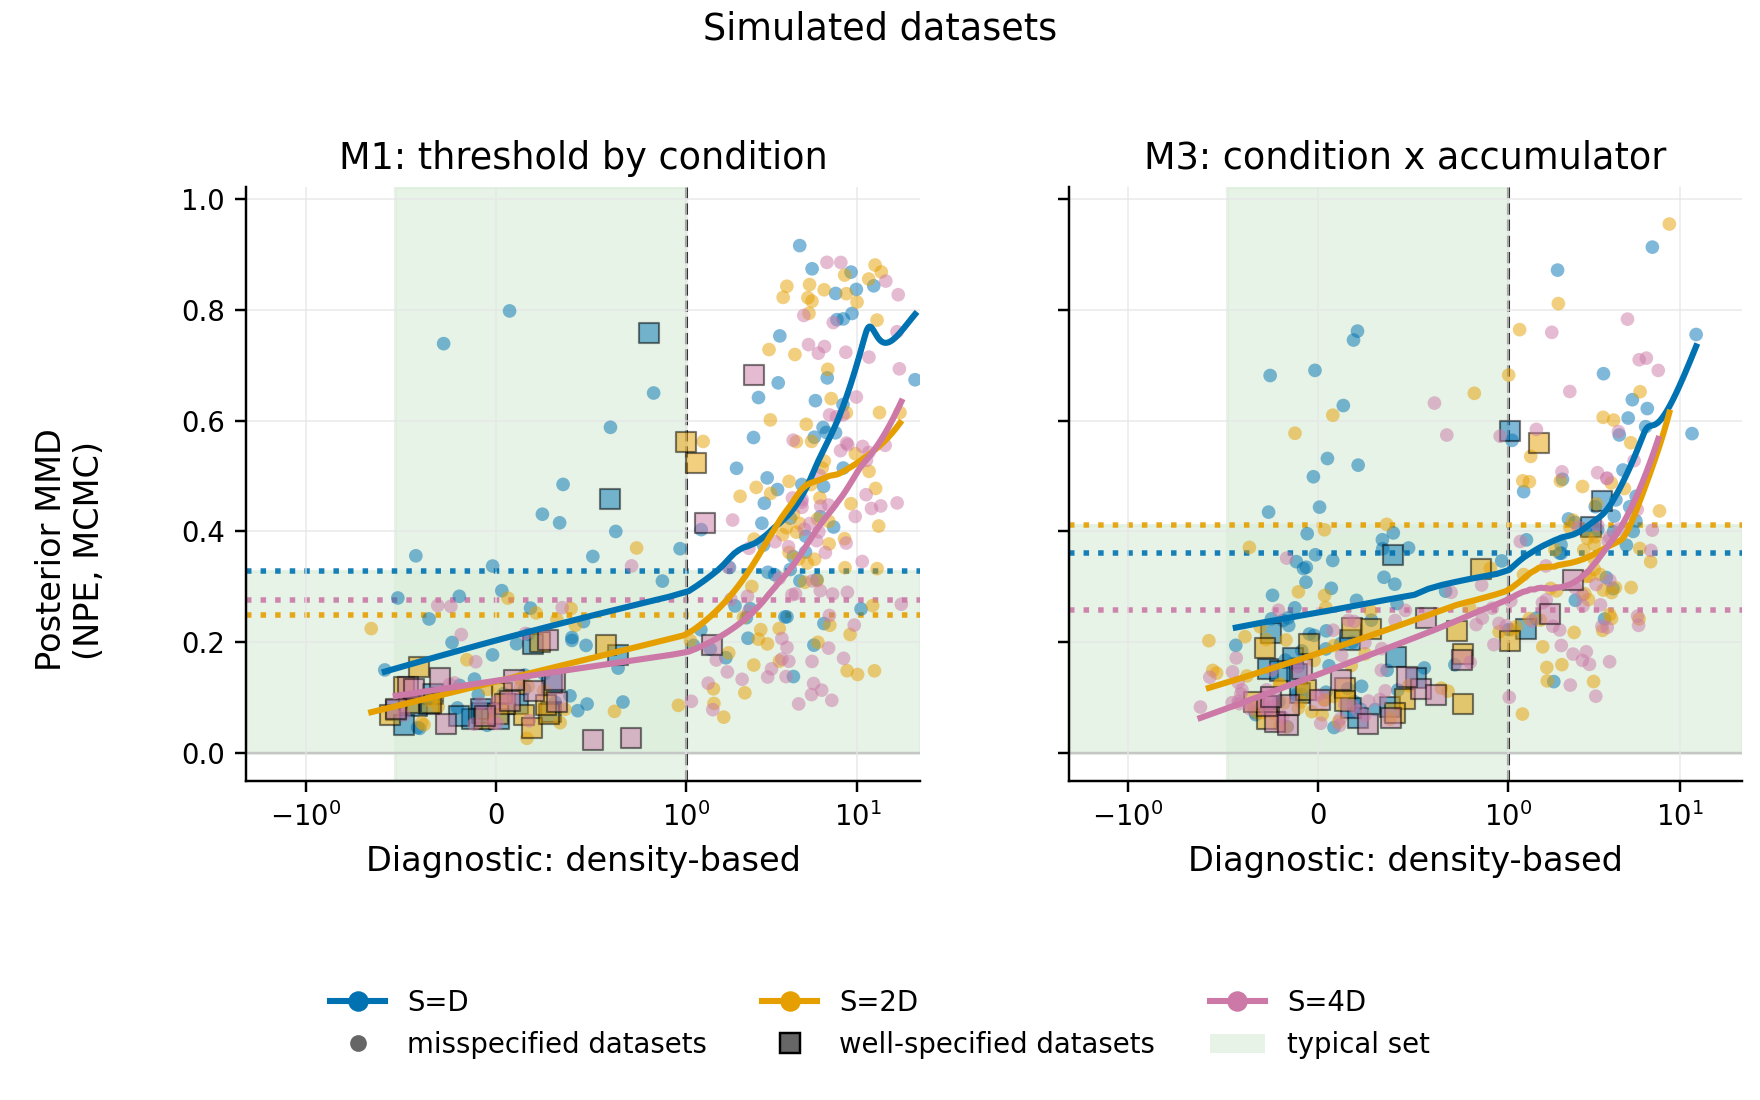

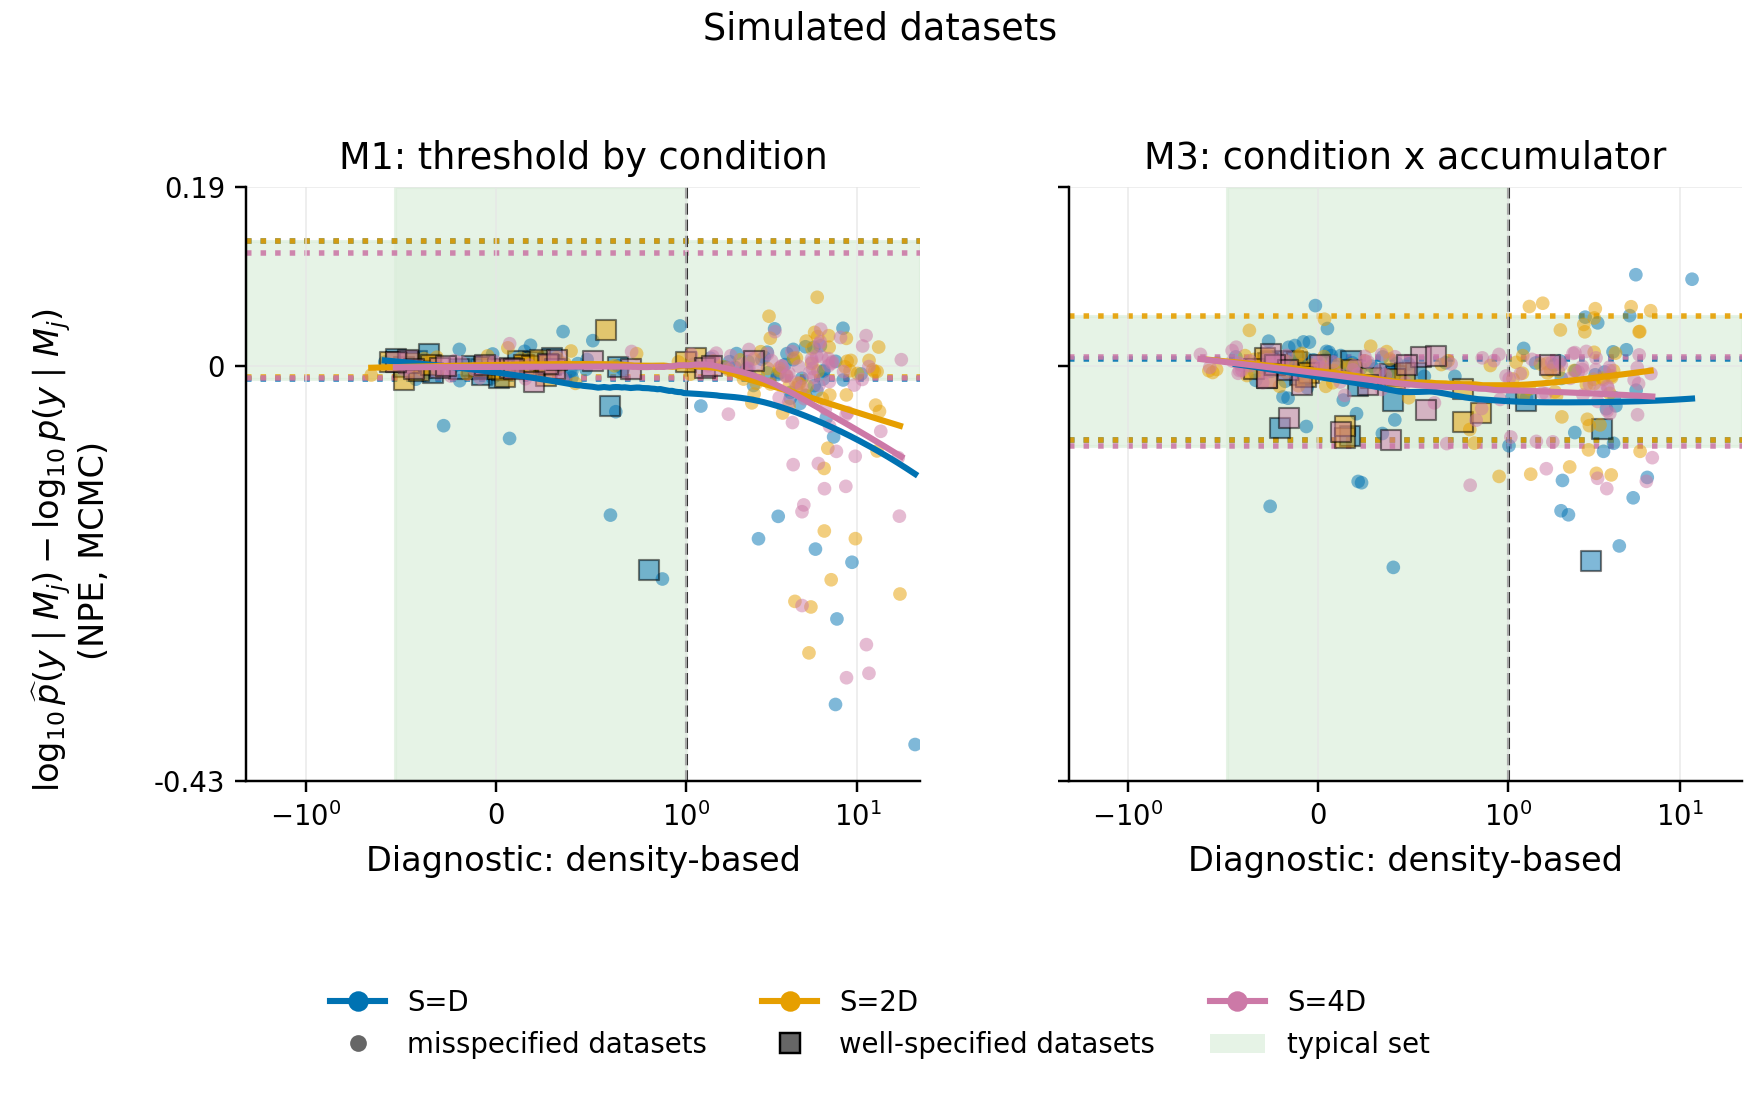

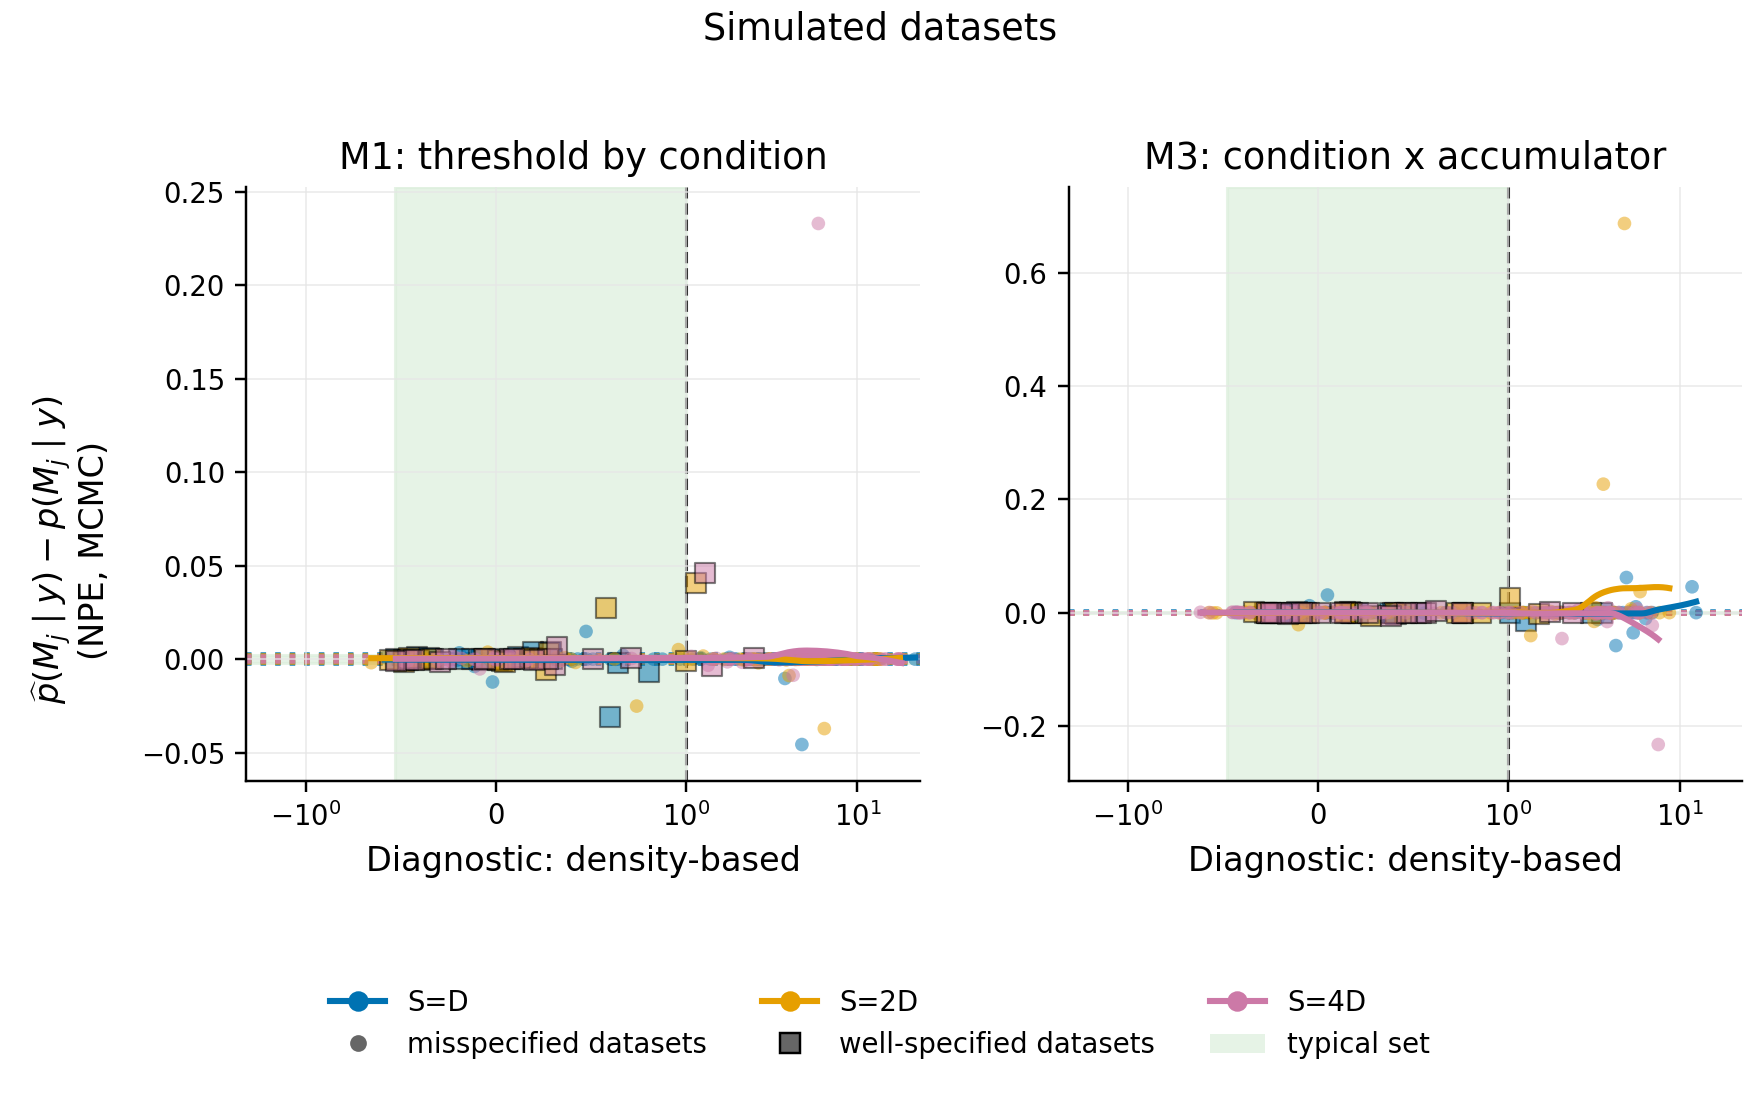

## Empirical datasets

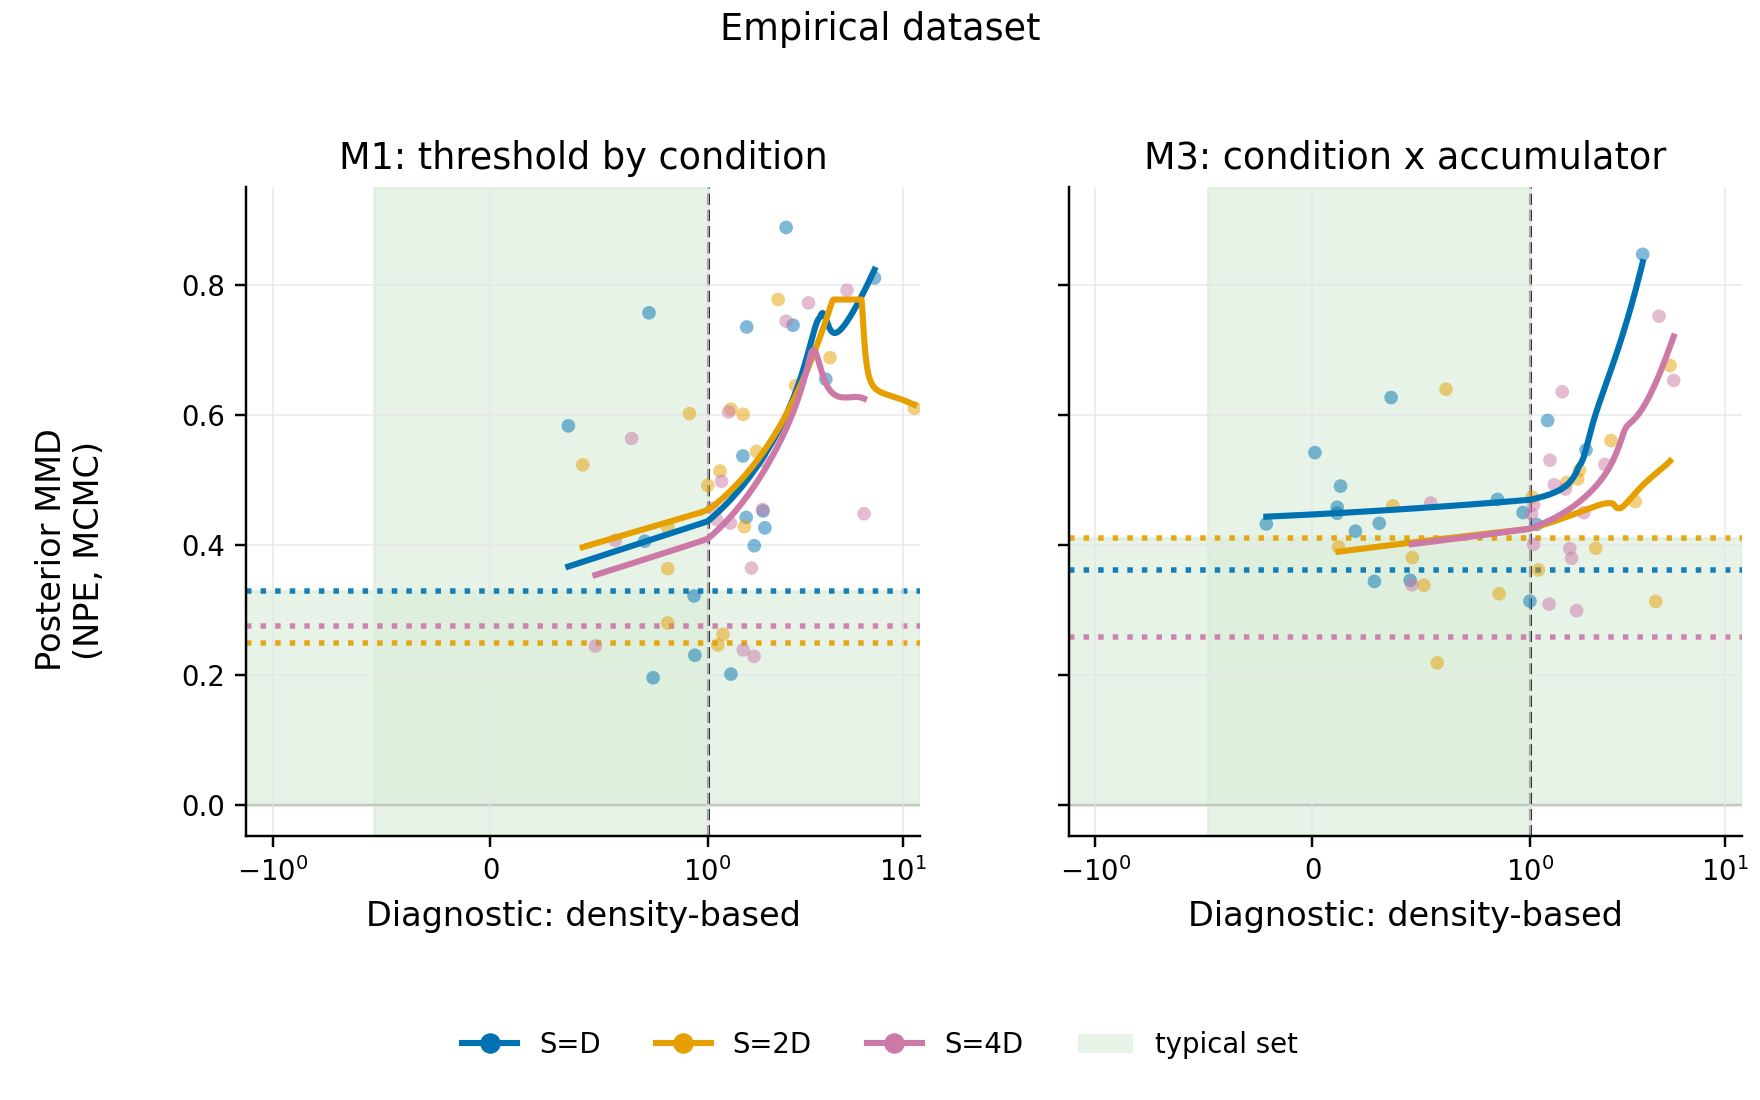

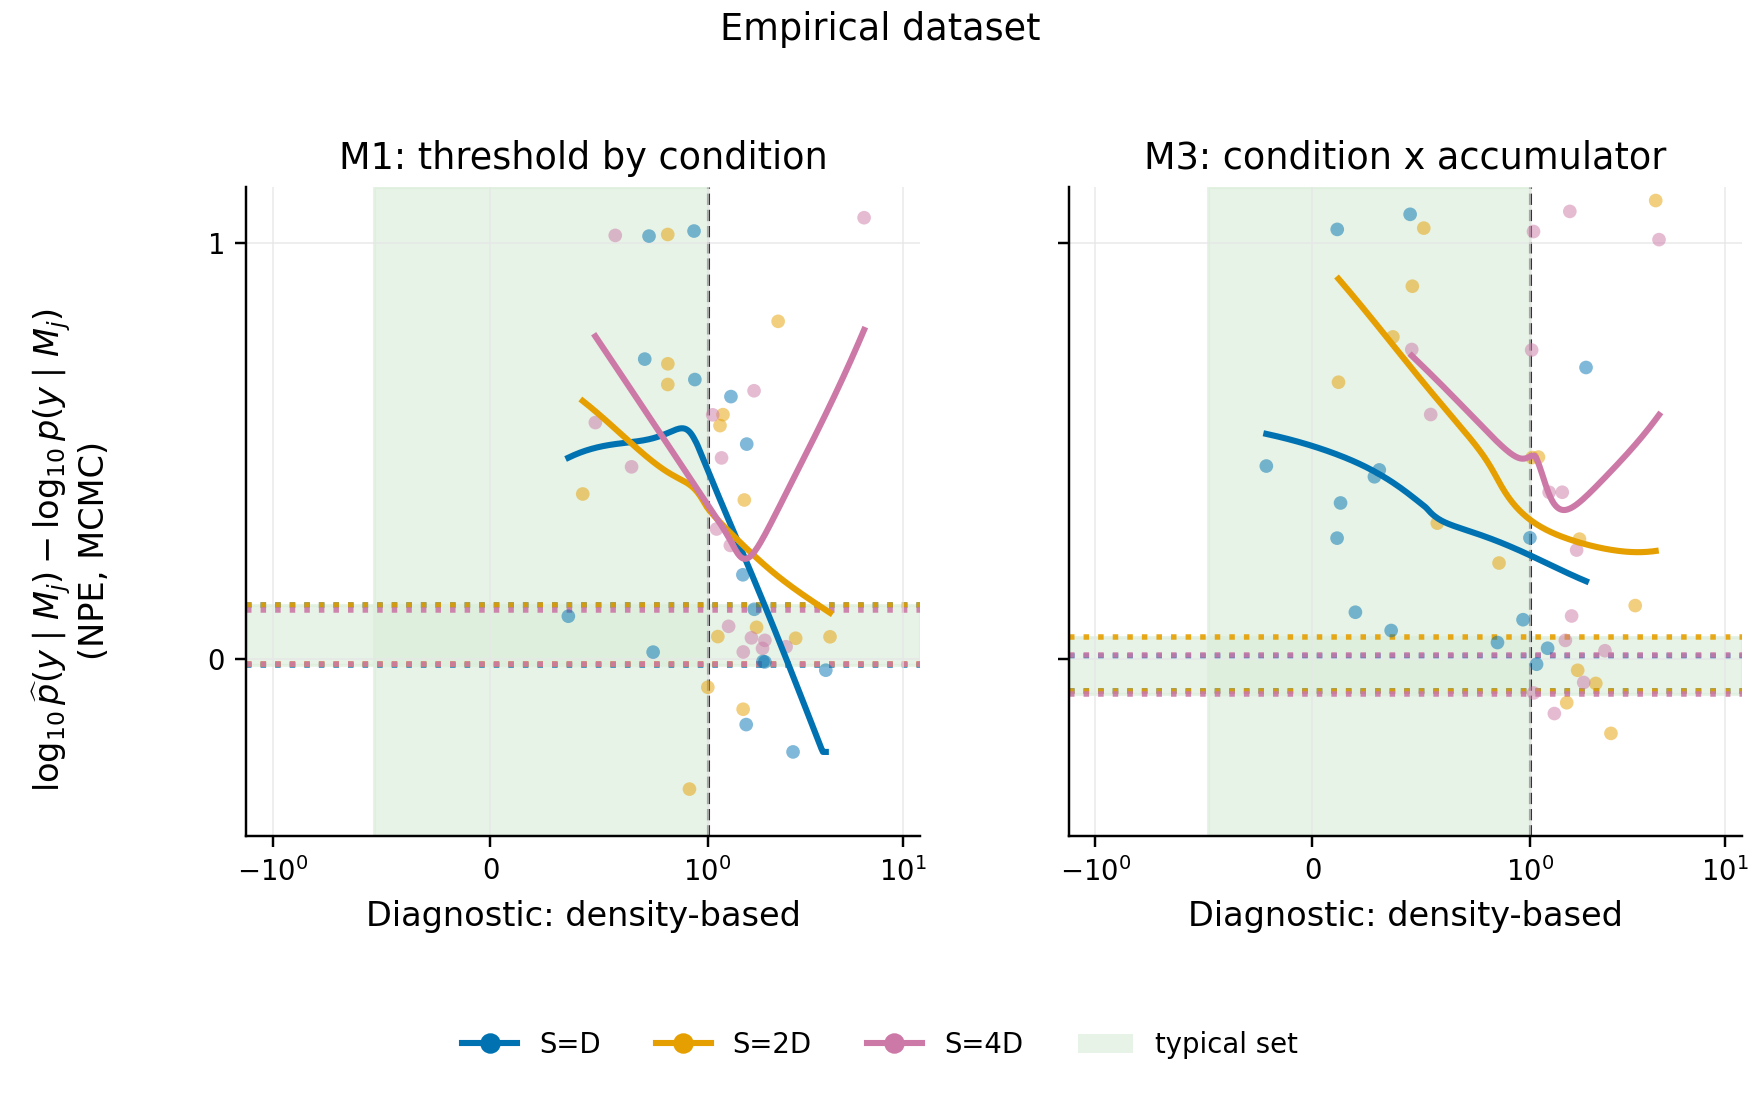

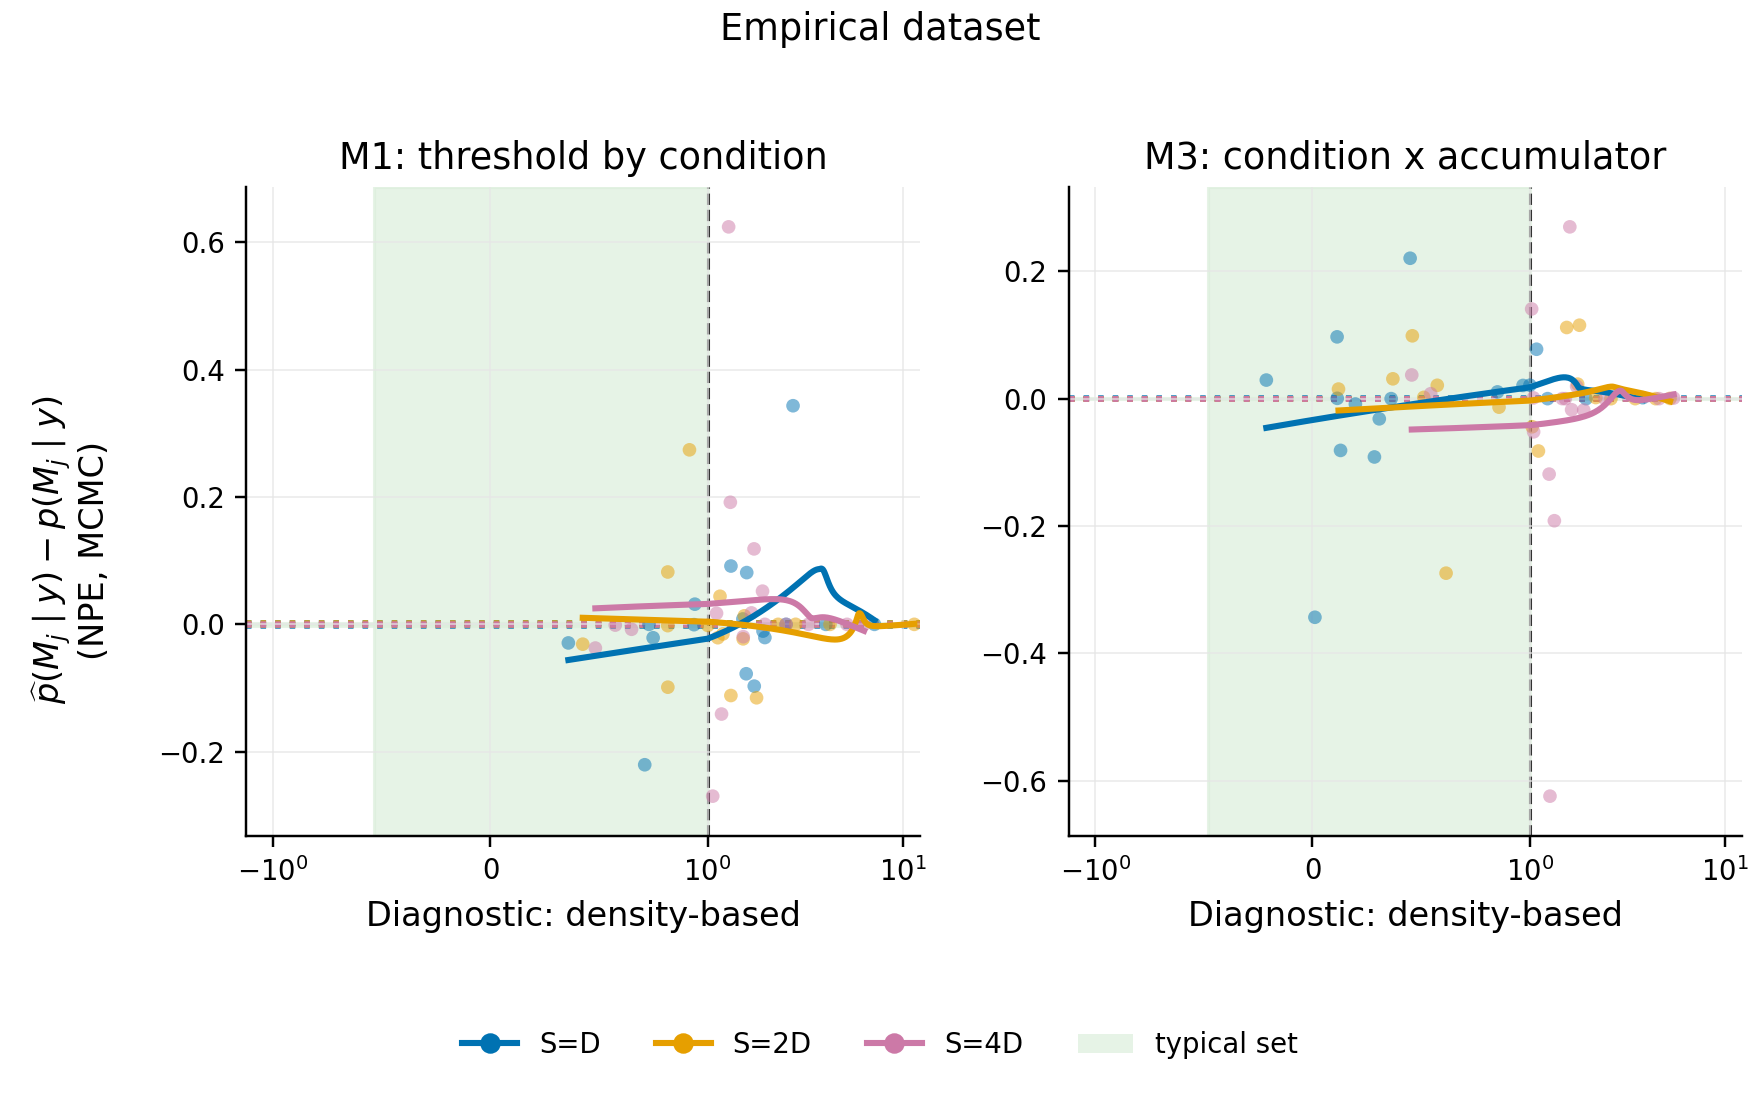

## Empirical PMP error vs. diagnostic $\rho$

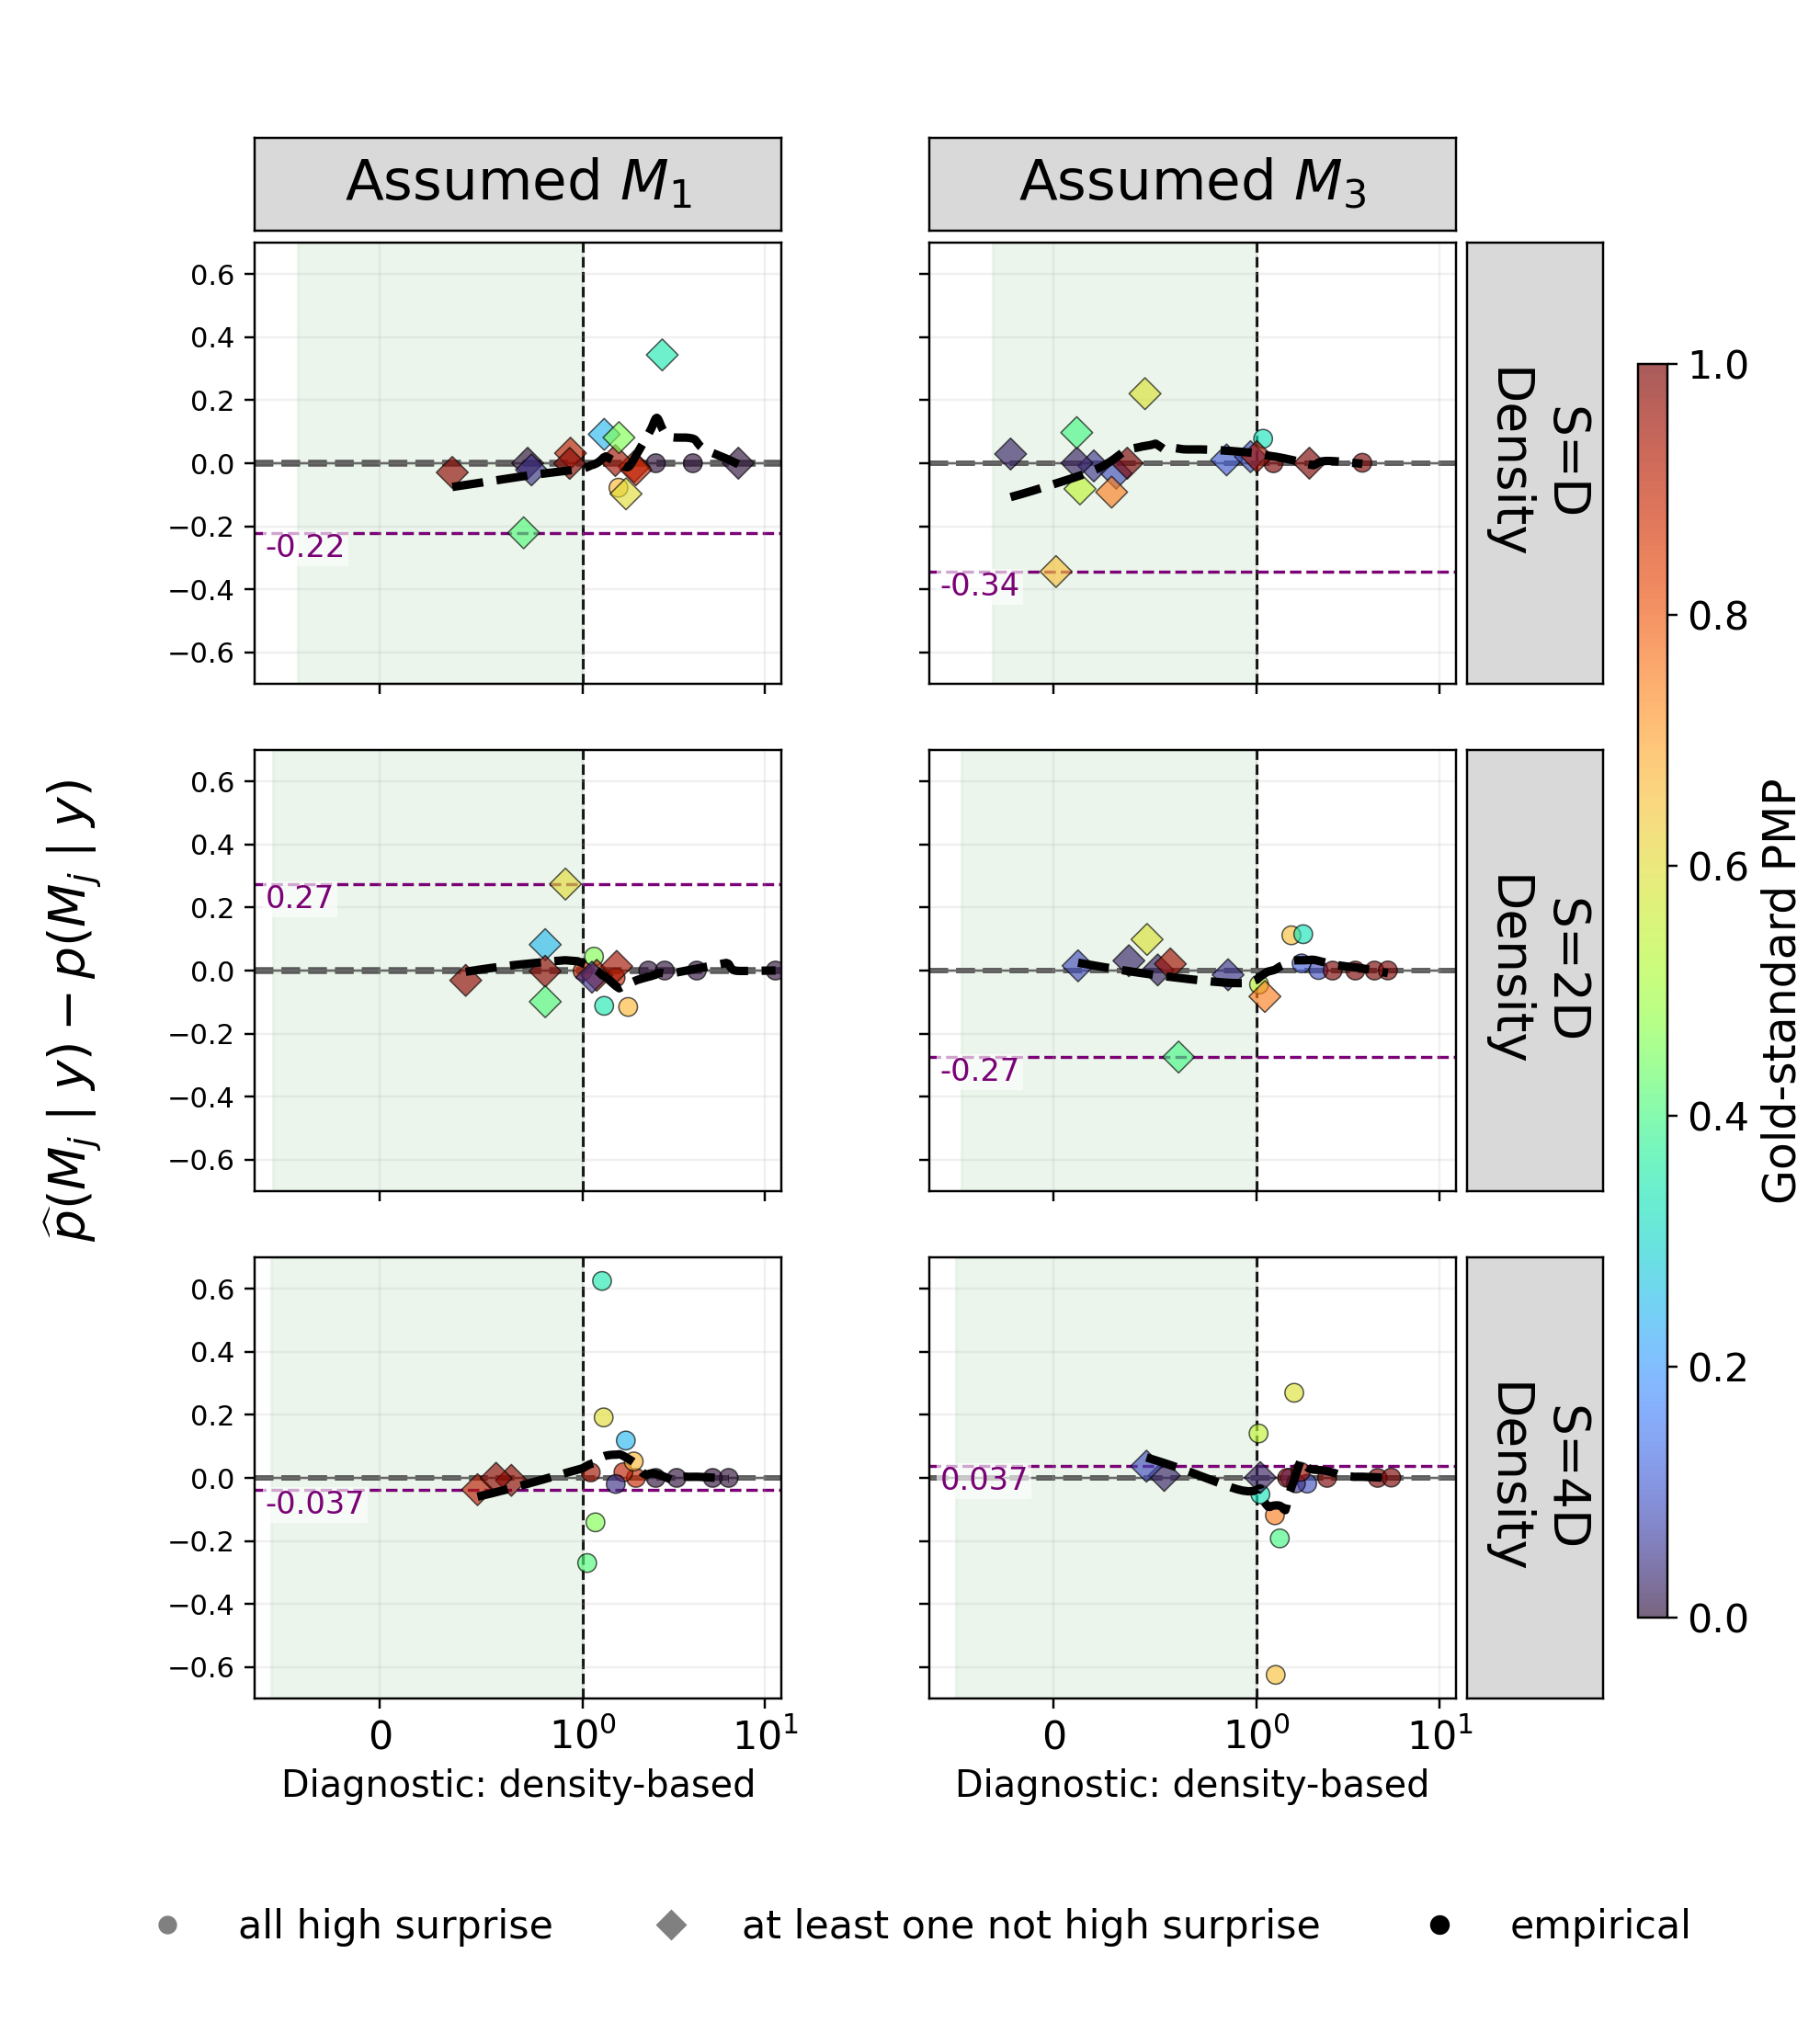

In [4]:
comparisons = run_calibrated_comparison_pipeline(
    metrics=METRICS,
    model_sets=MODEL_SETS,
    summary_specs=NO_MMD_SUMMARY_SPECS,
    output_root=OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
    normalize_metrics=NORMALIZE_METRICS,
    threshold_path=THRESHOLD_PATH,
)

for name, comparison in comparisons.items():
    print(name, comparison["output_root"])
    display_summary_dimension_comparison(comparison)

gold_pmp_paths = generate_calibrated_gold_pmp_lowess_grid(
    METRICS[0],
    output_root=OVERLAY_OUTPUT_ROOT,
    xscale=XSCALE,
    yscale=YSCALE,
    normalize_metrics=NORMALIZE_METRICS,
    threshold_path=THRESHOLD_PATH,
)
display_gold_pmp_lowess_grid(gold_pmp_paths)
